In [2]:
import duckdb as db 
import pandas as pd 
import pyarrow as py 
import matplotlib.pyplot as plt
import numpy as np

Flight log data spans from January 1, 2020 to November 30th, 2025.

In [3]:
UNCLEAN_PATH = "master_flights.parquet"

Define a flight being delayed as taking off more than 15 minutes after the sheduled time or landing more than 15 minutes after the expected time.

In [4]:
con = db.connect()

# Data Cleaning and Preprocessing

In [ ]:
con.execute(f"""
    COPY (
        SELECT
            FlightDate,
            Year,
            Quarter,
            Month,
            DayofMonth,
            DayOfWeek,

            CRSDepTime,
            CRSArrTime,
            DepTimeBlk,
            ArrTimeBlk,

            Reporting_Airline,
            DOT_ID_Reporting_Airline,

            OriginAirportID,
            Origin,
            OriginCityName,
            OriginState,
            OriginStateName,

            DestAirportID,
            Dest,
            DestCityName,
            DestState,
            DestStateName,

            DepTime,
            DepDelay,
            DepDelayMinutes,
            DepDel15,
            DepartureDelayGroups,
            DepTimeBlk,

            ArrTime,
            ArrDelay,
            ArrDelayMinutes,
            ArrDel15,
            ArrivalDelayGroups,
            ArrTimeBlk,

            CRSElapsedTime,
            ActualElapsedTime,
            AirTime,
            Distance,
            DistanceGroup,
            TaxiOut,
            TaxiIn,

            CarrierDelay,
            WeatherDelay,
            NASDelay,
            SecurityDelay,
            LateAircraftDelay

            FROM read_parquet('{UNCLEAN_PATH}')
            WHERE Diverted = 0
                AND Cancelled = 0 
                AND OriginState NOT IN ('PR', 'VI', 'TT')
                AND DestState NOT IN ('PR', 'VI', 'TT')
        )
        TO 'clean_flights.parquet'
        (FORMAT PARQUET);
 """)



In [74]:
PATH = "clean_flights.parquet"

In [75]:
total_flights = con.execute(f""" 
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    """).fetchone()[0]
print(total_flights)

36367047


In [73]:
total_delayed_flights = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE DepDelay > 15 OR ArrDelay > 15
    """).fetchone()[0]

print(total_delayed_flights)

8023000


So 8,023,000 flights were delayed in the datasets timeframe.

In [76]:
percent_flights_delayed = total_delayed_flights / total_flights

print(percent_flights_delayed)

0.22061180826697313


Roughly 22.1% of all flights were delayed in the datasets timefram.

In [77]:
flights_over_3_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 180
    """).fetchone()[0]

print(flights_over_3_hours)

5130845


In [78]:
delayed_flights_over_3_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 180 AND (DepDelay > 15 OR ArrDelay > 15)
    """).fetchone()[0]

print(delayed_flights_over_3_hours)

1286846


1,286,846 of all flights over 3 hours where delayed by 15 or more minutes.

In [79]:
percent_flights_delayed_over_3_hours = delayed_flights_over_3_hours / flights_over_3_hours

print(percent_flights_delayed_over_3_hours)

0.2508058614126913


And 25.1% of all flights over 3 hours where delayed by 15 or more minutes.

In [80]:
flights_over_5_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 300
    """).fetchone()[0]

delayed_flights_over_5_hours = con.execute(f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    WHERE AirTime > 300 AND (DepDelay > 15 OR ArrDelay > 15)
    """).fetchone()[0]

print(delayed_flights_over_5_hours)

print(delayed_flights_over_5_hours/flights_over_5_hours)


254021
0.2608096134279152


254021 of flights over 5 hours were delayed which was 26.1% of flights over 5 hours.

## Exploritory Graphs

In [81]:
df = con.execute(f"""
    SELECT DepDelayMinutes
    FROM read_parquet('{PATH}')
    USING SAMPLE 1000000 ROWS""").df()

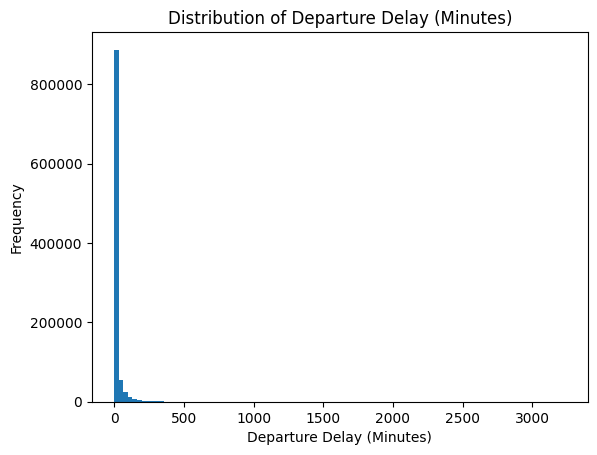

In [82]:
plt.hist(df["DepDelayMinutes"], bins = 100)
plt.title("Distribution of Departure Delay (Minutes)")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

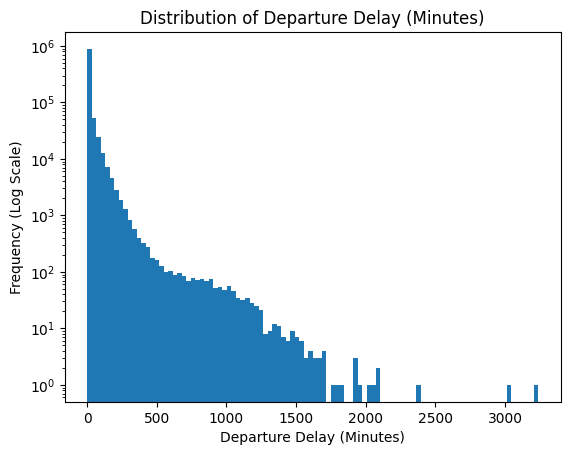

In [83]:
plt.hist(df["DepDelayMinutes"], bins = 100, log=True)
plt.title("Distribution of Departure Delay (Minutes)")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Frequency (Log Scale)")
plt.show()

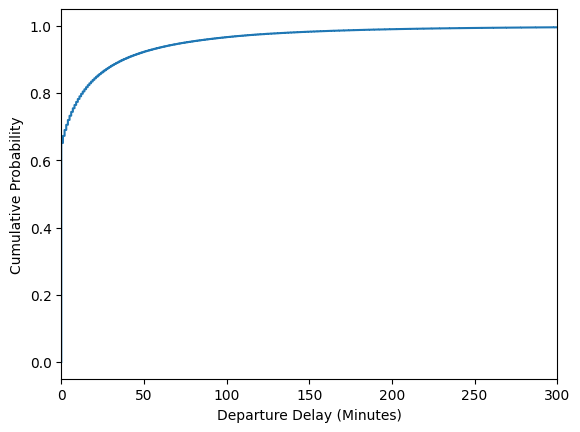

In [84]:
sorted_delays = np.sort(df["DepDelayMinutes"])
cdf = np.arange(len(sorted_delays)) / float(len(sorted_delays))

plt.plot(sorted_delays, cdf)
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Cumulative Probability")
plt.xlim(0, 300)
plt.show()

In [85]:
print(np.percentile(df["DepDelayMinutes"], [50, 75, 90, 95, 99]))

[  0.   7.  38.  74. 198.]


In [86]:
monthly_delay_rate = con.execute(f"""
    SELECT
        Year,
        Month,
        AVG(CASE 
            WHEN DepDelayMinutes > 15 OR ArrDelayMinutes > 15 THEN 1
            ELSE 0
        END) AS DelayRate
    FROM read_parquet('{PATH}')
    GROUP BY Year, Month
    ORDER BY Year, Month
""").df()

In [87]:
monthly_delay_rate["Date"] = pd.to_datetime(
    monthly_delay_rate["Year"].astype(str) + "-" + monthly_delay_rate["Month"].astype(str)
)

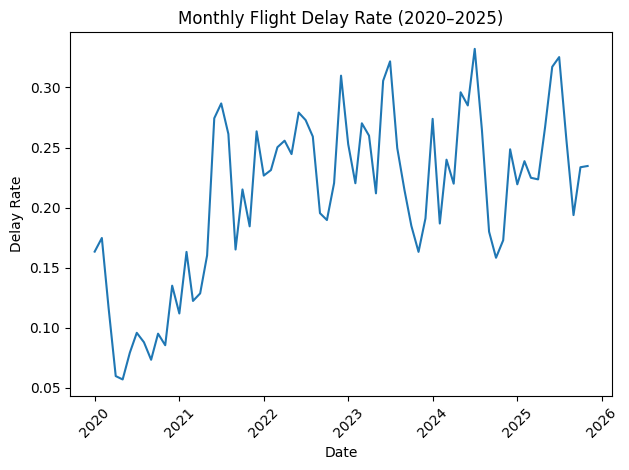

<Figure size 640x480 with 0 Axes>

In [150]:
plt.plot(monthly_delay_rate["Date"], monthly_delay_rate["DelayRate"])
plt.title("Monthly Flight Delay Rate (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig("MonthlyDelayRate.png")

Create histogram of distribution of type of delay

In [89]:
delay_counts = con.execute(f"""
    SELECT
        SUM(CASE WHEN CarrierDelay > 0 THEN 1 ELSE 0 END)      AS CarrierDelay,
        SUM(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END)      AS WeatherDelay,
        SUM(CASE WHEN NASDelay > 0 THEN 1 ELSE 0 END)          AS NASDelay,
        SUM(CASE WHEN SecurityDelay > 0 THEN 1 ELSE 0 END)     AS SecurityDelay,
        SUM(CASE WHEN LateAircraftDelay > 0 THEN 1 ELSE 0 END) AS LateAircraftDelay,
    FROM read_parquet('{PATH}')
    WHERE DepDelay > 15 OR ArrDelay > 15
""").fetchdf()

In [90]:
delay_counts = delay_counts.melt(var_name="DelayType", value_name="FlightCount")


In [91]:
print(delay_counts)

           DelayType  FlightCount
0       CarrierDelay    3828649.0
1       WeatherDelay     413389.0
2           NASDelay    3206297.0
3      SecurityDelay      35379.0
4  LateAircraftDelay    3356204.0


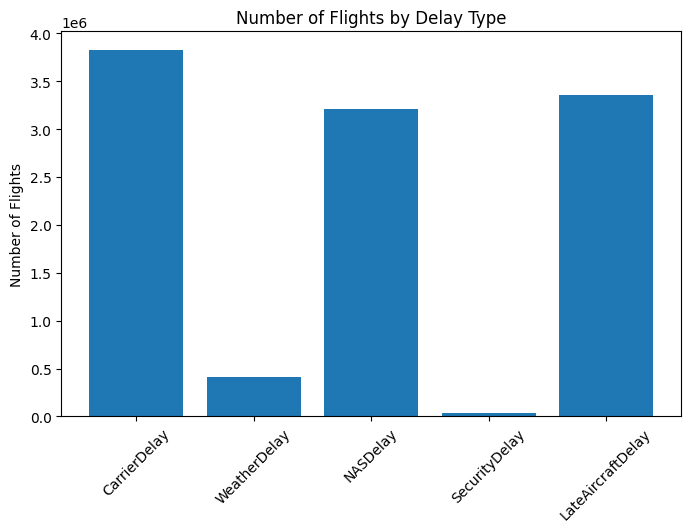

In [92]:
plt.figure(figsize=(8,5))
plt.bar(delay_counts["DelayType"], delay_counts["FlightCount"])
plt.xticks(rotation=45)
plt.ylabel("Number of Flights")
plt.title("Number of Flights by Delay Type")
plt.show()

In [93]:
unique_airports_count = con.execute(f"""
    SELECT COUNT(DISTINCT airport) AS num_airports
                                   
    FROM (SELECT Origin AS airport FROM read_parquet('{PATH}')   
    UNION
    SELECT Dest AS airport FROM read_parquet('{PATH}'))                           
    """).fetchone()[0]

print(unique_airports_count)

377


In [94]:
con.execute(f"""
    CREATE OR REPLACE TABLE airports_raw AS
    SELECT *
    FROM read_csv_auto('airports-extended.dat', header = False)        
            """)

In [95]:
con.execute(f"""
    CREATE OR REPLACE TABLE airports AS
    SELECT
        column01 AS airport_name,
        column02 AS city,
        column03 AS country,
        NULLIF(column04, '\\\\N') AS iata,
        CAST(column06 AS DOUBLE) AS latitude,
        CAST(column07 AS DOUBLE) AS longitude
    FROM airports_raw
    WHERE NULLIF(column04, '\\\\N') IS NOT NULL     
    """)

In [96]:
print(con.execute("SELECT * FROM airports LIMIT 5").fetchdf())

                                  airport_name          city  \
0                               Goroka Airport        Goroka   
1                               Madang Airport        Madang   
2                 Mount Hagen Kagamuga Airport   Mount Hagen   
3                               Nadzab Airport        Nadzab   
4  Port Moresby Jacksons International Airport  Port Moresby   

            country iata  latitude   longitude  
0  Papua New Guinea  GKA -6.081690  145.391998  
1  Papua New Guinea  MAG -5.207080  145.789001  
2  Papua New Guinea  HGU -5.826790  144.296005  
3  Papua New Guinea  LAE -6.569803  146.725977  
4  Papua New Guinea  POM -9.443380  147.220001  


In [64]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [97]:
print(con.execute("""
    SELECT DISTINCT OriginState
    FROM read_parquet('{}')
    ORDER BY OriginState
""".format(PATH)).fetchdf())

   OriginState
0           AK
1           AL
2           AR
3           AZ
4           CA
5           CO
6           CT
7           DE
8           FL
9           GA
10          HI
11          IA
12          ID
13          IL
14          IN
15          KS
16          KY
17          LA
18          MA
19          MD
20          ME
21          MI
22          MN
23          MO
24          MS
25          MT
26          NC
27          ND
28          NE
29          NH
30          NJ
31          NM
32          NV
33          NY
34          OH
35          OK
36          OR
37          PA
38          RI
39          SC
40          SD
41          TN
42          TX
43          UT
44          VA
45          VT
46          WA
47          WI
48          WV
49          WY


In [100]:
con.execute("""
CREATE OR REPLACE TABLE us_airports AS
SELECT
  iata,
  latitude,
  longitude
FROM airports
WHERE country = 'United States'
  AND iata IS NOT NULL
  AND iata != ''
""")

print(con.execute("SELECT * FROM us_airports LIMIT 5").fetchdf())

  iata   latitude   longitude
0  BTI  70.134003 -143.582001
1   \N  70.613403 -159.860001
2  LUR  68.875099 -166.110001
3  PIZ  69.732903 -163.005005
4  ITO  19.721399 -155.048004


In [104]:
con.execute(f"""
CREATE OR REPLACE TABLE flights_with_coords AS
SELECT
  f.*,
  o.latitude  AS origin_lat,
  o.longitude AS origin_lon,
  d.latitude  AS dest_lat,
  d.longitude AS dest_lon
FROM read_parquet('{PATH}') f
LEFT JOIN us_airports o ON f.Origin = o.iata
LEFT JOIN us_airports d ON f.Dest   = d.iata
""")

OutOfMemoryException: Out of Memory Error: failed to offload data block of size 128.0 KiB (12.2 GiB/12.2 GiB used).
This limit was set by the 'max_temp_directory_size' setting.
By default, this setting utilizes the available disk space on the drive where the 'temp_directory' is located.
You can adjust this setting, by using (for example) PRAGMA max_temp_directory_size='10GiB'

Possible solutions:
* Reducing the number of threads (SET threads=X)
* Disabling insertion-order preservation (SET preserve_insertion_order=false)
* Increasing the memory limit (SET memory_limit='...GB')

See also https://duckdb.org/docs/stable/guides/performance/how_to_tune_workloads

In [105]:
print(con.execute("""
SELECT
  COUNT(*) AS total_flights,
  SUM(CASE WHEN origin_lat IS NULL OR dest_lat IS NULL THEN 1 ELSE 0 END) AS missing_coords
FROM flights_with_coords
""").fetchdf())

   total_flights  missing_coords
0       36367047         17649.0


In [134]:
print(con.execute("""
SELECT
  CASE
    WHEN origin_lon IS NULL OR dest_lon IS NULL THEN NULL
    WHEN dest_lon > origin_lon THEN 'Eastbound'
    WHEN dest_lon < origin_lon THEN 'Westbound'
    ELSE NULL
  END AS direction,
  COUNT(*) AS flights,
  AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
FROM flights_with_coords
WHERE origin_lon IS NOT NULL AND dest_lon IS NOT NULL
GROUP BY 1
ORDER BY delay_rate DESC
""").fetchdf())

   direction   flights  delay_rate
0  Westbound  18175678    0.224252
1  Eastbound  18173720    0.216979


In [135]:
print(con.execute("""
SELECT
  CASE
    WHEN origin_lon IS NULL OR dest_lon IS NULL THEN NULL
    WHEN dest_lon > origin_lon THEN 'Eastbound'
    WHEN dest_lon < origin_lon THEN 'Westbound'
    ELSE NULL
  END AS direction,
  CASE 
      WHEN Month IN (12,1,2) THEN 'Winter'
      WHEN Month IN (6,7,8) THEN 'Summer'
      ELSE 'Other'
  END AS season,
  AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
FROM flights_with_coords
WHERE origin_lon IS NOT NULL 
  AND dest_lon IS NOT NULL
GROUP BY 1,2
ORDER BY season, direction
""").fetchdf())

   direction  season  delay_rate
0  Eastbound   Other    0.195722
1  Westbound   Other    0.201066
2  Eastbound  Summer    0.262811
3  Westbound  Summer    0.271559
4  Eastbound  Winter    0.211455
5  Westbound  Winter    0.221267


In [136]:
print(con.execute("""
SELECT
  Month,
  AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
FROM flights_with_coords
GROUP BY Month
ORDER BY delay_rate DESC
""").fetchdf())

    Month  delay_rate
0       7    0.285842
1       6    0.277178
2       8    0.239051
3      12    0.235346
4       5    0.228555
5       1    0.212056
6       4    0.210602
7       3    0.208301
8       2    0.203893
9      10    0.185189
10     11    0.182130
11      9    0.177865


In [138]:
df_hour_counts = con.execute("""
WITH base AS (
  SELECT
    CASE
      WHEN CAST(CRSDepTime AS INTEGER) = 2400 THEN 0
      ELSE FLOOR(CAST(CRSDepTime AS INTEGER) / 100)
    END AS dep_hour,
    ArrDelayMinutes,
    DepDelayMinutes
  FROM flights_with_coords
  WHERE CRSDepTime IS NOT NULL
)
SELECT
  dep_hour,
  COUNT(*) AS flights,
  AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
FROM base
WHERE dep_hour BETWEEN 0 AND 23
GROUP BY dep_hour
ORDER BY dep_hour
""").fetchdf()

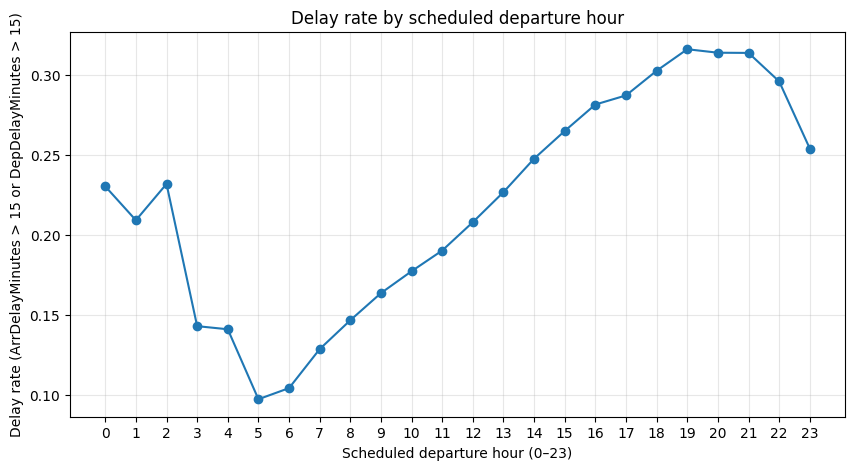

<Figure size 640x480 with 0 Axes>

In [149]:
plt.figure(figsize=(10,5))
plt.plot(df_hour_counts["dep_hour"], df_hour_counts["delay_rate"], marker="o")
plt.xticks(range(0,24))
plt.xlabel("Scheduled departure hour (0–23)")
plt.ylabel("Delay rate (ArrDelayMinutes > 15 or DepDelayMinutes > 15)")
plt.title("Delay rate by scheduled departure hour")
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("DelayRateByHour.png")

In [148]:
print(df_hour_counts.sort_values("delay_rate", ascending=False))

    dep_hour  flights  delay_rate
19      19.0  1941117    0.316071
20      20.0  1619347    0.313886
21      21.0  1160716    0.313763
18      18.0  2202114    0.302599
22      22.0   814910    0.295936
17      17.0  2284012    0.287183
16      16.0  2096197    0.281474
15      15.0  2138466    0.264951
23      23.0   275107    0.253941
14      14.0  2123984    0.247628
2        2.0     3671    0.231817
0        0.0    59958    0.230295
13      13.0  2216599    0.226697
1        1.0    17044    0.209106
12      12.0  2199477    0.207903
11      11.0  2327456    0.190170
10      10.0  2329837    0.177217
9        9.0  2114750    0.163520
8        8.0  2524603    0.146551
3        3.0      637    0.142857
4        4.0      440    0.140909
7        7.0  2531216    0.128498
6        6.0  2519270    0.104106
5        5.0   866119    0.097154


In [140]:
print(df_hour_counts["dep_hour"].min(), df_hour_counts["dep_hour"].max())
print(len(df_hour_counts))

0.0 23.0
24


In [141]:
print(con.execute("""
    SELECT
    Origin,
    COUNT(*) AS flights,
    AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
    FROM flights_with_coords
    GROUP BY Origin
    HAVING COUNT(*) > 5000
    ORDER BY delay_rate DESC
    """).fetch_df())

    Origin  flights  delay_rate
0      LCK     5977    0.332943
1      ASE    35376    0.326860
2      BLV     6648    0.307762
3      BWI   495771    0.287796
4      MDW   420119    0.281389
5      TTN    10051    0.281266
6      MIA   533397    0.280204
7      MVY     5386    0.279985
8      FLL   463618    0.278514
9      DAL   377688    0.276763
10     MCO   779758    0.273881
11     SFB    53476    0.270738
12     DEN  1582247    0.270389
13     EGE    17450    0.270086
14     HDN    12876    0.269028
15     EYW    44023    0.267974
16     ORH     6079    0.267643
17     EWR   625725    0.266673
18     DFW  1615329    0.263897
19     LAS   956168    0.262756
20     PBI   143424    0.253905
21     JFK   585529    0.252896
22     FNT    15032    0.252262
23     ACK     8092    0.250741
24     HOU   295996    0.250260
25     JAC    31156    0.248684
26     PVU     9606    0.247554
27     ISP    25744    0.247475
28     PGD    35711    0.247011
29     ORD  1484037    0.238699
30     P

In [142]:
print(con.execute("""
    SELECT
        Reporting_Airline,
        COUNT(*) AS flights,
        AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
    FROM flights_with_coords
    GROUP BY Reporting_Airline
    ORDER BY delay_rate DESC;
    """).fetch_df())

   Reporting_Airline  flights  delay_rate
0                 B6  1180952    0.304477
1                 F9   878702    0.303822
2                 G4   655739    0.275613
3                 NK  1169739    0.263050
4                 WN  7225127    0.249966
5                 AA  4788454    0.249486
6                 AS  1243461    0.223865
7                 UA  3472819    0.221911
8                 OH  1236842    0.209360
9                 MQ  1457862    0.197277
10                YV   392853    0.195844
11                HA   400773    0.184024
12                OO  4183588    0.182906
13                DL  5028071    0.182769
14                YX  1722870    0.168565
15                QX   196481    0.157048
16                9E  1084733    0.138181
17                EV    47981    0.119610


In [143]:
print(con.execute("""
    SELECT
        Reporting_Airline,
        AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
    FROM flights_with_coords
    WHERE Month NOT IN (6,7,8)
    GROUP BY Reporting_Airline
    ORDER BY delay_rate DESC;
""").fetch_df())

   Reporting_Airline  delay_rate
0                 F9    0.285783
1                 B6    0.285492
2                 G4    0.259160
3                 NK    0.249047
4                 WN    0.229548
5                 AA    0.225084
6                 AS    0.213631
7                 UA    0.202033
8                 OH    0.194007
9                 HA    0.187199
10                MQ    0.186431
11                YV    0.180183
12                OO    0.175213
13                DL    0.167067
14                QX    0.156197
15                YX    0.153549
16                9E    0.127390
17                EV    0.126788


In [144]:
print(con.execute("""
    SELECT
        Origin,
        COUNT(*) AS flights,
        AVG(CASE WHEN ArrDelayMinutes > 15 OR DepDelayMinutes > 15 THEN 1 ELSE 0 END) AS delay_rate
    FROM flights_with_coords
    GROUP BY Origin
    HAVING COUNT(*) > 500000
    ORDER BY delay_rate DESC;
""").fetch_df())

   Origin  flights  delay_rate
0     MIA   533397    0.280204
1     MCO   779758    0.273881
2     DEN  1582247    0.270389
3     EWR   625725    0.266673
4     DFW  1615329    0.263897
5     LAS   956168    0.262756
6     JFK   585529    0.252896
7     ORD  1484037    0.238699
8     BOS   687424    0.230433
9     CLT  1120917    0.230198
10    IAH   668986    0.227770
11    DCA   676208    0.226416
12    BNA   501263    0.225415
13    LGA   746178    0.225310
14    PHX   979698    0.214838
15    SEA   906893    0.210898
16    SFO   707303    0.204966
17    ATL  1806198    0.203599
18    LAX  1034083    0.199575
19    DTW   719902    0.185795
20    MSP   681411    0.184184
21    SLC   641263    0.176244
